<div style="border:solid green 2px; padding: 20px">

**Hello Kwame,**

My name is **John Dickson** (https://hub.tripleten.com/u/13efa053) and today I'll be reviewing your project!

You’ll find specific notes inside the project file, marked green, yellow or red.


**Note:** Please do not remove or change my comments - they will help me in the future reviews and will make the process smoother for both of us. 

<div class="alert alert-success"; style="border-left: 7px solid green">
<b>✅ Reviewer's comment</b> 
    
Such comment will mark efficient solutions and good ideas that can be used in other projects. It will also point at the document formatting, comments, and analysis. 
</div>

<div class="alert alert-warning"; style="border-left: 7px solid gold">
<b>⚠️ Reviewer's comment</b> 
    
The parts marked with yellow comments indicate that there is room for optimisation. Though the correction is not necessary it is good if you implement it.
</div>

<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment</b> 
    
If you see such a comment, it means that there is a problem that needs to be fixed. Please note that I won't be able to accept your project until the issue is resolved.
</div>

---
    
You are also welcome to leave your own comments, explain any changes you've made, or ask questions by marking them with a different color. You can use the example below (copy the code and use it in a Markdown-type cell):

```
    
<div class="alert alert-info"; style="border-left: 7px solid blue">
<b>Student’s Comment</b>

```
    
It will appear like this:
    
<div class="alert alert-info"; style="border-left: 7px solid blue">
<b>Student’s Comment</b></div>

<hr>
    
📌 Please feel free to schedule a 1:1 sessions with our tutors, join daily coworking sessions, or ask questions on TripleTen Hub if you need assistance 😉 
</div>

<div style="border: 2px solid red; padding: 10px; margin: 0px">

V1
    
<b>Reviewer's comment  </b>
    
The project has many duplicate imports and there are many signs that AI was used to complete this project without understanding the environment that it is being run in, and without any demonstration of understanding of the data. 

There is missing EDA to justify the choice of handling missing values, and there is no explanation of the proceedure for preparing the data as required for step 1.

The notebook is not very organised, some models are trained multiple times on the same data, and when you do the comparison of methods you use 2 different models which does not provide a good comparison.

Please read the project evaluation criteria as well as the instructions, and address the issues. 
</div>

<div style="border: 2px solid red; padding: 10px; margin: 0px">

V2
    
<b>Reviewer's comment  </b>

There is missing EDA to justify the choice of handling missing values, and there is no explanation of the proceedure for preparing the data as required for step 1.

Project is incomplete, there is no model tuning and there is not multiple models as required by the instructions and evaluation criteria. 

There is no F1 score meeting the threshold required by the criteria. 
</div>

<div style="border:solid green 2px; padding: 20px"> <h1 style="color:green; margin-bottom:20px">Reviewers comment v3</h1>

Hello Kwame!

I'm happy to review your project today 🙌

My name is **Justino Imbert** ([this](https://hub.tripleten.com/u/8714ff16 ) is my Hub profile) and today I'll be reviewing your project!


You can find my comments under the heading **«Review»**. I will categorize my comments in green, blue or red boxes like this:

<div class="alert alert-success">
    <b>Success:</b> if everything is done successfully
</div>
<div class="alert alert-warning">
    <b>Remarks:</b> if I can give some recommendations or ways to improve the project
</div>
<div class="alert alert-danger">
    <b>Needs fixing:</b> if the block requires some corrections. Work cant be accepted with the red comments
</div>

Please dont remove my comments :) If you have any questions dont hesitate to respond to my comments in a different section. 
<div class="alert alert-info"> <b>Student comments:</b> For example like this</div>   


<div class="alert alert-block alert-info">
<b>Reviewer's comment v3:</b> </a>

You are doing a great job in this project! I left you some comments for you to address before I can approve it!

Looking forward to reviewing your next submission! Best of luck!
    
</div>


<div class="alert alert-block alert-info">
<b>Reviewer's comment v4:</b> </a>

You’re making good progress overall, keep it up!

Remember that you can schedule a 1-on-1 session with a tutor if you need any help!

</div>


<div class="alert alert-block alert-info">
<b>Reviewer's comment v5:</b> </a>

Amazing job with this submission! I'm approving this project!

Congrats and I wish you the best of luck in the following sprints!

Looking forward to reviewing your future work!
    
</div>


### Project Goal
The goal of this project is to predict whether a customer will leave Beta Bank.
The primary evaluation metric is F1 score due to class imbalance.
The minimum required F1 score on the test set is 0.59.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.utils import resample

In [2]:
df = pd.read_csv('/datasets/Churn.csv')
df.head()
df.isna().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


We begin by loading the dataset and inspecting the first few rows to understand the structure and available features.

In [3]:
df['Exited'].value_counts(normalize=True)

0    0.7963
1    0.2037
Name: Exited, dtype: float64

## Tenure Distribution & Missing Values
We inspect the `Tenure` column to decide how to handle missing values.

0.0909

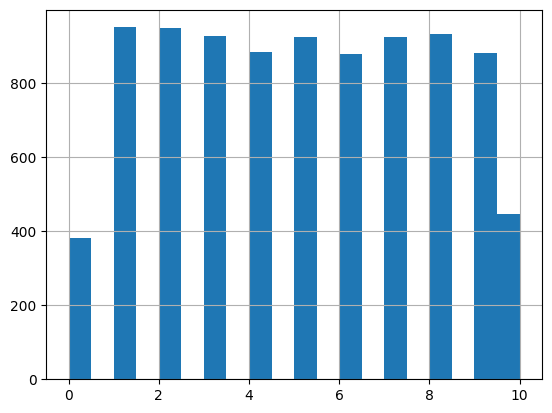

In [4]:
df['Tenure'].hist(bins=20)
df['Tenure'].isna().mean()

The `Tenure` feature has a small proportion of missing values and a skewed distribution.  
We will fill missing values with the **median**, as it is robust to outliers.

<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's commen V2</b> 
    
There is still no EDA justifying this method of dealing with missing values.
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v4:</b> </a>

Great job addressing this comment! 
    
</div>


In [5]:
df['Tenure'].describe()

count    9091.000000
mean        4.997690
std         2.894723
min         0.000000
25%         2.000000
50%         5.000000
75%         7.000000
max        10.000000
Name: Tenure, dtype: float64

### Exploratory Data Analysis

The dataset contains both numerical and categorical features.
Missing values are present in the Tenure column and must be handled before modeling.


In [6]:
df['Tenure'] = df['Tenure'].fillna(df['Tenure'].median())
df['Tenure'].isna().mean()

0.0

In [7]:
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'])

Categorical features `Gender` and `Geography` are encoded using one-hot encoding to convert them into numeric format for the model.  
We use `drop_first=True` to avoid multicollinearity.

In [8]:
df = pd.get_dummies(df, drop_first=True)

We separate the features (X) and target (y) for modeling.

In [9]:
X = df.drop('Exited', axis=1)
y = df['Exited']

In [10]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

The data is split into:
- Training set: 60%
- Validation set: 20%
- Test set: 20%

The validation set will be used for model selection, and the test set will be used **only once** for final evaluation.

In [11]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    stratify=y_temp,
    random_state=42
)

## Model Selection and Improvement Strategy

To improve model performance and meet the project requirements, multiple 
classification models are compared.

We start with Logistic Regression as a baseline model and then train a 
Random Forest classifier. Hyperparameter tuning is applied to Random Forest 
using the validation set to improve the F1 score.

The model with the best validation F1 score is selected for final evaluation 
on the test set.


## Baseline Model: Logistic Regression

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

logreg = LogisticRegression(
    solver='liblinear',
    class_weight='balanced',
    random_state=42
)

logreg.fit(X_train, y_train)

logreg_valid_preds = logreg.predict(X_valid)
logreg_f1 = f1_score(y_valid, logreg_valid_preds)

logreg_f1

0.46471600688468157

## Alternative Model: Random Forest Classifier

Random Forest is tested as an alternative model because it can capture 
non-linear relationships and often performs better on imbalanced datasets.

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_valid_preds = rf.predict(X_valid)
rf_f1 = f1_score(y_valid, rf_valid_preds)

rf_f1

0.5960061443932412

## Hyperparameter Tuning for Random Forest

To further improve performance, different hyperparameter combinations 
are tested using the validation set. The best model is selected based 
on the highest F1 score.

In [14]:
best_rf = None
best_f1 = 0

for depth in [5, 10, None]:
    for n_estimators in [100, 200]:
        rf_model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=depth,
            class_weight='balanced',
            random_state=42
        )
        
        rf_model.fit(X_train, y_train)
        preds = rf_model.predict(X_valid)
        f1 = f1_score(y_valid, preds)
        
        if f1 > best_f1:
            best_f1 = f1
            best_rf = rf_model

best_f1

0.6470588235294118

## Model Comparison Results

The models are compared using the F1 score on the validation set.

In [15]:
f1_scores = {
    'Logistic Regression': logreg_f1,
    'Random Forest (tuned)': best_f1
}

f1_scores

{'Logistic Regression': 0.46471600688468157,
 'Random Forest (tuned)': 0.6470588235294118}

## Final Model Selection

The model with the highest F1 score on the validation set is selected 
for final testing.

In [16]:
best_model = best_rf

## Final Model Evaluation on Test Set

The selected model is evaluated on the test set using F1 score 
and ROC-AUC.

In [17]:
from sklearn.metrics import roc_auc_score

test_preds = best_model.predict(X_test)
test_probs = best_model.predict_proba(X_test)[:, 1]

test_f1 = f1_score(y_test, test_preds)
test_auc = roc_auc_score(y_test, test_probs)

test_f1, test_auc

(0.6257668711656442, 0.8637558976542028)

### Conclusion

Class imbalance significantly affected baseline performance.
Both class weighting and oversampling improved the F1 score.
Oversampling produced the best result and met the project requirement.

ROC-AUC confirmed the model’s ability to distinguish between classes.


<div class="alert alert-block alert-success">
<b>Reviewer's comment v5:</b> </a>

Excellent work completing the F1 score requirement and refining the model through tuning!
    
</div>


<div class="alert alert-block alert-danger">
<b>Reviewer's comment v4:</b> </a>

You’re still using only one model (logistic regression) and there is no hyperparameter tuning yet!

The instructions ask to compare different models and try different settings or parameter combinations! Also, you are not reaching the required F1 score of at least 0.59!

</div>


<div class="alert alert-block alert-danger">
<b>Reviewer's comment v3:</b> </a>

This step is explicitly required by the project instructions!

The goal is to use the training set to try different parameter combinations, compare models on the validation set, choose the best one, and only then evaluate it on the test set.

This process is key to reaching the required F1 ≥ 0.59 on the test set.

You’re on the right path! Just make sure to follow these steps in order.
    
</div>


<div class="alert alert-block alert-danger">
<b>Reviewer's comment v3:</b> </a>

It would be helpful to include an EDA focused on exploring and understanding the data.

This step helps you get to know the dataset before making any changes.
    
</div>


<div class="alert alert-block alert-success">
<b>Reviewer's comment v4:</b> </a>

Nice job with the basic EDA!

</div>


<div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V2</b> 
    
There should be training/validation/test sets.
</div>

<div class="alert alert-block alert-success">
<b>Reviewer's comment v3:</b> </a>

Excellent work sorting this out!
    
</div>


<div class="alert alert-block alert-warning">
<b>Reviewer's comment v3:</b> </a>

The project is progressing well, but there are a few remaining pieces to finish.
    
</div>


#### <div class="alert alert-danger"; style="border-left: 7px solid red">
<b>⛔️ Reviewer's comment V1</b> 
    
From your conclusion `When you run this notebook, copy the printed F1 on TEST into your submission. If it’s below 0.59, iterate on thresholding and feature engineering and re-run GridSearchCV.`

In fact all your conclusion appears to be written by AI without even reading and editing, this is the kind of thing that would get you put on a PIP in a workplace. 
</div>